<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('/online_retail.csv')

In [12]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


EDA

In [14]:
df.isnull().sum()


,0
index,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


We have 135k missing customer ids. Remove these from our data set since we can't segment customers if we can't match them to their purchases.

In [15]:
df.dropna(subset=['CustomerID'], inplace=True)

In [16]:
df.isnull().sum()

,0
index,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


We can see we no longer have missing values.

In [17]:
df.duplicated().sum()

np.int64(0)

No rows are duplicates, we are good on that front.

We also want to remove cancelled orders, since we want to understand our customers that are purchasing things. (maybe would be interesting to look into cancellation stuff later)

In [18]:
df_no_cancelled = df[~df['InvoiceNo'].astype(str).str.startswith('c')]
# ~ inverts the boolean


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


RFM analysis

In [20]:
# Add a revenue line
df_no_cancelled['Revenue'] = df_no_cancelled['Quantity'] * df_no_cancelled['UnitPrice']
df_no_cancelled.head() # Display the first few rows with the new 'Revenue' column

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [23]:
# Recency
from datetime import timedelta
df_no_cancelled['InvoiceDate'] = pd.to_datetime(df_no_cancelled['InvoiceDate'])
snapshot_date = df_no_cancelled['InvoiceDate'].max() + timedelta(days=1) # Think of this as last day in the set + 1 (current day)


In [24]:
# Create new RFM dataframe
rfm_df = df_no_cancelled.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'),                                    # Number of unique invoices
    Monetary=('Revenue', 'sum')                                            # Total revenue
)
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


(0.0, 10000.0)

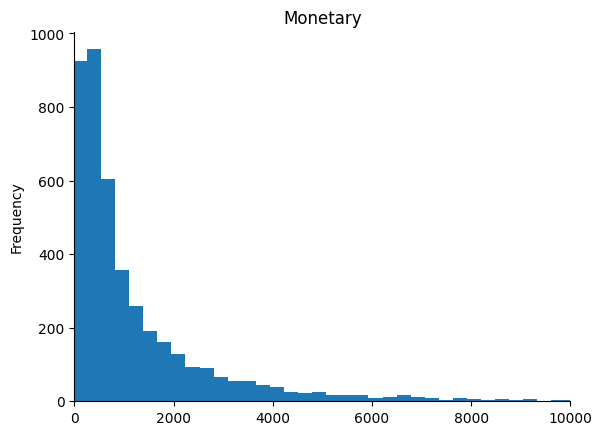

In [35]:
# @title Monetary

from matplotlib import pyplot as plt
rfm_df['Monetary'].plot(kind='hist', bins=1000, title='Monetary')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 10000)

(0.0, 50.0)

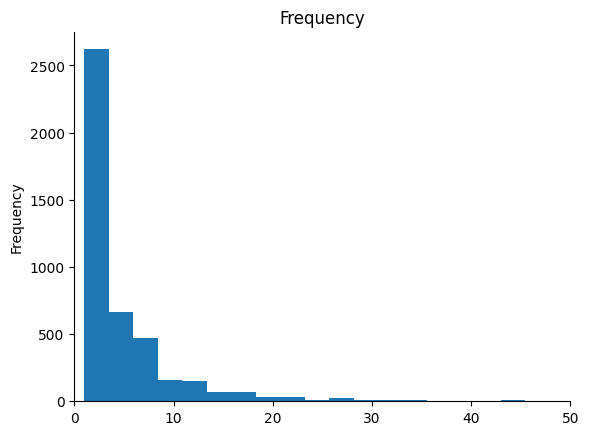

In [38]:
# @title Frequency

from matplotlib import pyplot as plt
rfm_df['Frequency'].plot(kind='hist', bins=100, title='Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 50)

(0.0, 400.0)

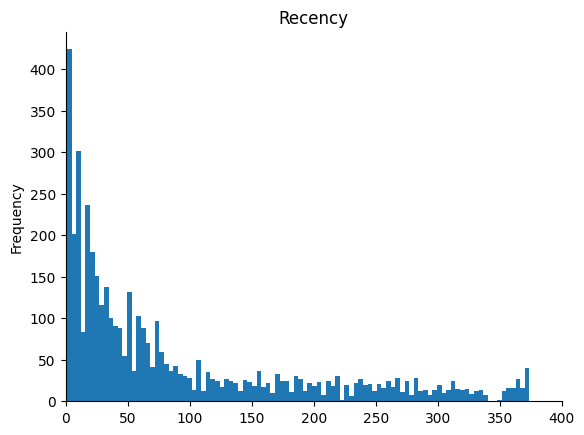

In [41]:
# @title Recency

from matplotlib import pyplot as plt
rfm_df['Recency'].plot(kind='hist', bins=100, title='Recency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 400)